1. Obtenção e preparação dos dados. Baixe o arquivo
PDB da estrutura 6B1T a partir de https://www.
rcsb.org/structure/6B1T (opção de download do
pacote comprimido tar.gz). Para testes preliminares,
selecione proteínas menores disponíveis no
mesmo repositório, que permitam validar a cadeia
de processamento sem sobrecarga de memória.

2. Leitura e parsing do arquivo PDB. Utilize pacote
específico ou implemente um leitor para extrair as
informações de cada átomo.

3. Construção da rede. Modele a proteína como um
grafo não-dirigido, podendo ser unitário ou ponderado. 
A justificativa detalhada da modelagem deve constar
no relatório final, e deve ter uma boa fundamentação.

In [2]:
from Bio.PDB import PDBParser
import networkx as nx
import numpy as np
from scipy.spatial import KDTree


def build_protein(pdb_paths_list, distance_cutoff=7.0):
    """Lê um arquivo no formato .pdb tradicional e constrói a rede usando NetworkX.

    Nós: Carbonos Alfa (CA) de cada resíduo.
    Arestas: Criadas se a distância espacial for <= distance_cutoff.
    """
    # 1. Parsing do arquivo .pdb tradicional
    parser = PDBParser(QUIET=True)

    atoms_info = []
    coords = []

    for pdb_path in pdb_paths_list:
        print(f"Lendo estrutura do arquivo: {pdb_path}")
        structure = parser.get_structure("protein_part", pdb_path)
        structure = parser.get_structure("protein", pdb_path)
        for model in structure:
            for chain in model:
                for residue in chain:
                    # Mantém apenas os Carbonos Alfa para economizar memória [cite: 5, 11]
                    if "CA" in residue:
                        atom = residue["CA"]
                        atoms_info.append(
                            {
                                "res_id": residue.get_id()[1],
                                "res_name": residue.get_resname(),
                                "chain_id": chain.get_id(),
                            }
                        )
                        coords.append(atom.get_coord())
            break  # Foca apenas no primeiro modelo biológico

    coords = np.array(coords)
    n_nodes = len(coords)
    print(f"Processando {n_nodes} resíduos...")

    # 2. Inicializa o Grafo do NetworkX
    G = nx.Graph()

    # 3. Adiciona os nós com metadados estruturais [cite: 13, 21]
    for i, info in enumerate(atoms_info):
        G.add_node(
            i,
            res_id=info["res_id"],
            res_name=info["res_name"],
            chain_id=info["chain_id"],
        )

    # 4. Busca espacial por proximidade (KDTree) [cite: 15]
    tree = KDTree(coords)
    pairs = tree.query_pairs(r=distance_cutoff)

    # 5. Conecta os nós por distância [cite: 13, 15]
    G.add_edges_from(pairs)

    print(f"Rede NetworkX criada com sucesso a partir do arquivo PDB!")
    print(f"Total de Vértices: {G.number_of_nodes()}")
    print(f"Total de Arestas: {G.number_of_edges()}")

    return G


# --- Exemplo de uso ---
arquivos_6b1t = [
    # "./6b1t-pdb-bundle1.pdb",
    # "./6b1t-pdb-bundle2.pdb"
    "./1a8o.pdb1"
]

G_teste = build_protein(arquivos_6b1t, distance_cutoff=7.0)

Lendo estrutura do arquivo: ./1a8o.pdb1
Processando 70 resíduos...
Rede NetworkX criada com sucesso a partir do arquivo PDB!
Total de Vértices: 70
Total de Arestas: 256


4. Análise topológica da rede. Calcule e interprete as
seguintes medidas:
• distribuição de graus ;
• centralidades convenientes ;


--- Analisando Propriedades Topológicas: 1A8O_Teste ---
Grau Médio dos nós: 7.31
Grau Máximo encontrado: 11


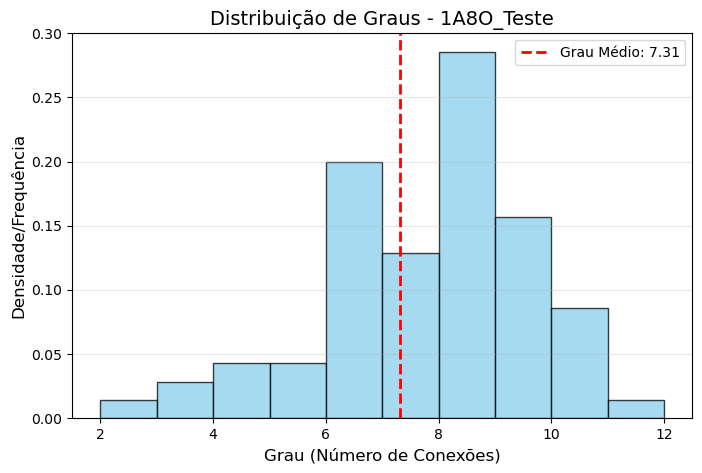

Calculando Centralidade de Grau...

[RESULTADO] Top 5 Aminoácidos mais Centrais (Hubs Estruturais):
 Nó 48: LYS-199 (Cadeia A) -> Centralidade: 0.1594
 Nó 13: TYR-164 (Cadeia A) -> Centralidade: 0.1449
 Nó 35: THR-186 (Cadeia A) -> Centralidade: 0.1449
 Nó 40: VAL-191 (Cadeia A) -> Centralidade: 0.1449
 Nó 43: ALA-194 (Cadeia A) -> Centralidade: 0.1449

Calculando Centralidade de Intermediação (Betweenness)...

[RESULTADO] Top 5 Aminoácidos de Intermediação (Pontes/Dobradiças):
 Nó 35: THR-186 (Cadeia A) -> Betweenness: 0.1666
 Nó 60: LEU-211 (Cadeia A) -> Betweenness: 0.1202
 Nó 64: MSE-215 (Cadeia A) -> Betweenness: 0.1178
 Nó 4: GLN-155 (Cadeia A) -> Betweenness: 0.1119
 Nó 31: LYS-182 (Cadeia A) -> Betweenness: 0.0925


In [20]:
import collections
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np


def analyze_topological_properties(G, protein_name="Proteina"):
    """Calcula e interpreta a distribuição de graus e centralidades."""
    print(f"\n--- Analisando Propriedades Topológicas: {protein_name} ---")

    # 1. CÁLCULO DA DISTRIBUIÇÃO DE GRAUS (Etapa 4)
    degrees = [d for n, d in G.degree()]
    avg_degree = np.mean(degrees)
    max_degree = np.max(degrees)
    print(f"Grau Médio dos nós: {avg_degree:.2f}")
    print(f"Grau Máximo encontrado: {max_degree}")

    # Plotando a Distribuição de Graus (Salvar para o Relatório/Slides)
    plt.figure(figsize=(8, 5))
    plt.hist(
        degrees,
        bins=range(min(degrees), max(degrees) + 2),
        density=True,
        alpha=0.75,
        color="skyblue",
        edgecolor="black",
    )
    plt.axvline(
        avg_degree,
        color="red",
        linestyle="dashed",
        linewidth=2,
        label=f"Grau Médio: {avg_degree:.2f}",
    )
    plt.title(f"Distribuição de Graus - {protein_name}", fontsize=14)
    plt.xlabel("Grau (Número de Conexões)", fontsize=12)
    plt.ylabel("Densidade/Frequência", fontsize=12)
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.savefig(f"distribuicao_graus_{protein_name}.png")
    plt.show()

    # 2. CENTRALIDADE CONVENIENTE: Degree Centrality (Rápida e ótima para o Alvo)
    print("Calculando Centralidade de Grau...")
    deg_centrality = nx.degree_centrality(G)

    # Identificar os 5 resíduos mais centrais (Hubs)
    top_hubs = sorted(deg_centrality.items(), key=lambda x: x[1], reverse=True)[
        :5
    ]

    print("\n[RESULTADO] Top 5 Aminoácidos mais Centrais (Hubs Estruturais):")
    for node_idx, centrality_val in top_hubs:
        res_info = G.nodes[node_idx]
        print(
            f" Nó {node_idx}: {res_info['res_name']}-{res_info['res_id']} "
            f"(Cadeia {res_info['chain_id']}) -> Centralidade: {centrality_val:.4f}"
        )

    # 3. EXTRA (Opcional - Rodar APENAS se o grafo for pequeno, ex: proteína de teste)
    if G.number_of_nodes() < 2000:
        print("\nCalculando Centralidade de Intermediação (Betweenness)...")
        between_centrality = nx.betweenness_centrality(G)
        top_bridges = sorted(
            between_centrality.items(), key=lambda x: x[1], reverse=True
        )[:5]

        print(
            "\n[RESULTADO] Top 5 Aminoácidos de Intermediação (Pontes/Dobradiças):"
        )
        for node_idx, centrality_val in top_bridges:
            res_info = G.nodes[node_idx]
            print(
                f" Nó {node_idx}: {res_info['res_name']}-{res_info['res_id']} "
                f"(Cadeia {res_info['chain_id']}) -> Betweenness: {centrality_val:.4f}"
            )


# --- Como chamar no seu bloco principal ---
analyze_topological_properties(G_teste, "1A8O_Teste")
# analyze_topological_properties(G_definitivo, "6B1T_Alvo")

5. Detecção de comunidades. Aplique ao menos um
algoritmos de detecção de comunidades (ex.: Louvain,
Infomap, ou Bipartição espectral). Reporte o
número de comunidades encontradas.

In [23]:
import networkx as nx


def detect_protein_communities(G, protein_name="Proteina"):
    """Calcula as comunidades usando o algoritmo de Louvain e analisa a composição

    biológica de cada uma para a Etapa 5 e 6.
    """
    print(f"\n--- Iniciando Detecção de Comunidades: {protein_name} ---")

    # 1. Executa o Algoritmo de Louvain (Etapa 5)
    # Retorna uma lista de conjuntos (sets), onde cada conjunto contém os índices dos nós daquela comunidade
    communities = list(nx.community.louvain_communities(G, seed=42))
    num_communities = len(communities)

    print(f"Sucesso! Encontradas {num_communities} comunidades na rede.")

    # 2. Calcula a Modularidade do Agrupamento
    # Essa métrica valida matematicamente a qualidade das comunidades detectadas
    modularity_val = nx.community.modularity(G, communities)
    print(f"Modularidade da rede: {modularity_val:.4f}")

    # 3. Análise da Composição Biológica por Comunidade (Preparação para a Etapa 6)
    print("\n=== COMPOSIÇÃO DAS COMUNIDADES (Mapeamento de Cadeias) ===")

    for idx, community in enumerate(communities):
        # Tamanho da comunidade (número de resíduos nela)
        tamanho = len(community)

        # Coleta todas as cadeias (chain_id) presentes nesta comunidade específica
        cadeias_na_comunidade = set(
            [G.nodes[node]["chain_id"] for node in community]
        )

        # Ordena as cadeias para o print ficar bonito
        lista_cadeias_ordenada = sorted(list(cadeias_na_comunidade))

        # Formata a string de cadeias separadas por vírgula para colar no site do RCSB
        string_para_o_site = ", ".join(lista_cadeias_ordenada)

        print(f"\n🔹 Comunidade {idx}:")
        print(f"  - Quantidade de nós (aminoácidos): {tamanho}")
        print(f"  - Cadeias contidas: {lista_cadeias_ordenada}")
        print(
            f"  - Texto para copiar e colorir no site: {string_para_o_site}"
        )

    return communities


# --- Como chamar no seu bloco principal ---
com_teste = detect_protein_communities(G_teste, "1A8O_Teste")
# com_definitiva = detect_protein_communities(G_definitivo, "6B1T_Alvo")

# 'communities' são as 6 comunidades que o seu Louvain acabou de encontrar para a 1A8O
for idx, community in enumerate(com_teste):
    # Coleta o res_id de cada nó pertencente a esta comunidade
    residuos_ids = [G_teste.nodes[node]['res_id'] for node in community]
    
    # Ordena os números e junta por vírgula (ex: 5, 6, 7, 12, 13)
    lista_numeros_formatada = ", ".join(map(str, sorted(residuos_ids)))
    
    print(f"Comunidade {idx} (Escolha uma cor para ela):")
    print(f"{lista_numeros_formatada}\n")


--- Iniciando Detecção de Comunidades: 1A8O_Teste ---
Sucesso! Encontradas 6 comunidades na rede.
Modularidade da rede: 0.6113

=== COMPOSIÇÃO DAS COMUNIDADES (Mapeamento de Cadeias) ===

🔹 Comunidade 0:
  - Quantidade de nós (aminoácidos): 10
  - Cadeias contidas: ['A']
  - Texto para copiar e colorir no site: A

🔹 Comunidade 1:
  - Quantidade de nós (aminoácidos): 7
  - Cadeias contidas: ['A']
  - Texto para copiar e colorir no site: A

🔹 Comunidade 2:
  - Quantidade de nós (aminoácidos): 13
  - Cadeias contidas: ['A']
  - Texto para copiar e colorir no site: A

🔹 Comunidade 3:
  - Quantidade de nós (aminoácidos): 15
  - Cadeias contidas: ['A']
  - Texto para copiar e colorir no site: A

🔹 Comunidade 4:
  - Quantidade de nós (aminoácidos): 13
  - Cadeias contidas: ['A']
  - Texto para copiar e colorir no site: A

🔹 Comunidade 5:
  - Quantidade de nós (aminoácidos): 12
  - Cadeias contidas: ['A']
  - Texto para copiar e colorir no site: A
Comunidade 0 (Escolha uma cor para ela):
151,

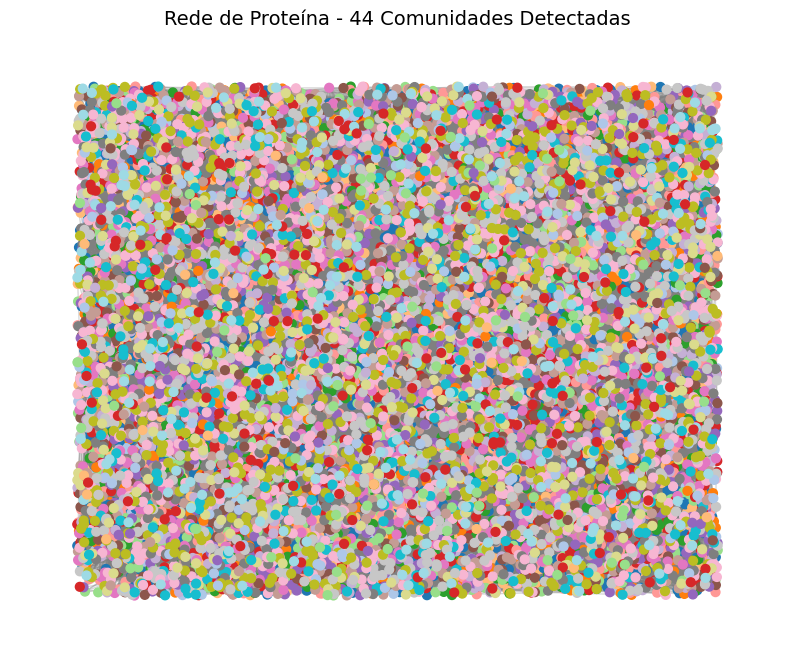

In [17]:
import matplotlib.pyplot as plt
import networkx as nx


def plot_protein_network(G):
    """Calcula as comunidades e plota o grafo em 2D colorido."""
    # 1. Calcula as comunidades usando Louvain (Etapa 5 do projeto)
    communities = list(nx.community.louvain_communities(G))

    # Cria um dicionário mapeando cada nó à sua respectiva comunidade
    node_community = {}
    for community_idx, community in enumerate(communities):
        for node in community:
            node_community[node] = community_idx

    # Gera a lista de cores para os nós baseada na comunidade deles
    colors = [node_community[node] for node in G.nodes()]

    # 2. Configura o layout de plotagem
    plt.figure(figsize=(10, 8))
    # 'kamada_kawai_layout' funciona muito bem para manter nós geometricamente próximos juntos
    # pos = nx.kamada_kawai_layout(G)
    pos = nx.random_layout(G)

    # 3. Desenha o grafo
    nx.draw_networkx_nodes(
        G, pos, node_size=40, node_color=colors, cmap=plt.cm.tab20
    )
    nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color="gray")

    plt.title(
        f"Rede de Proteína - {len(communities)} Comunidades Detectadas",
        fontsize=14,
    )
    plt.axis("off")
    plt.show()


# --- Como chamar após gerar o grafo de teste ---
plot_protein_network(G_teste)

In [3]:
import networkx as nx
# Roda as comunidades no grafo final
communities_6b1t = list(nx.community.louvain_communities(G_teste))


print("=== COPIE E COLE AS CADEIAS NO SITE ===")
for idx, community in enumerate(communities_6b1t):
    # Coleta as cadeias únicas daquela comunidade
    cadeias = set([G_teste.nodes[node]['chain_id'] for node in community])
    
    # Formata como 'A, B, C, D...'
    lista_formatada = ", ".join(sorted(list(cadeias)))
    
    print(f"Comunidade {idx} (Pinte de uma cor única):")
    print(f"{lista_formatada}\n")

=== COPIE E COLE AS CADEIAS NO SITE ===
Comunidade 0 (Pinte de uma cor única):
A

Comunidade 1 (Pinte de uma cor única):
A

Comunidade 2 (Pinte de uma cor única):
A

Comunidade 3 (Pinte de uma cor única):
A

Comunidade 4 (Pinte de uma cor única):
A



In [7]:
import json

# Paleta de cores para os teus clusters
cores_clusters = [
    "#E6194B", "#3CB44B", "#FFE119", "#4363D8", "#F58231", "#911EB4",
    "#46F0F0", "#F032E6", "#BCF60C", "#FABEBE", "#008080", "#E6BEFF"
]

user_data = []

for cluster_id, community in enumerate(communities_6b1t):
    cor_hex = cores_clusters[cluster_id % len(cores_clusters)]
    
    for node_idx in community:
        node_attr = G_teste.nodes[node_idx]
        
        # Mapeamos usando os três seletores possíveis do Mol* para evitar erros
        user_data.append({
            "label_asym_id": node_attr['chain_id'],
            "auth_asym_id": node_attr['chain_id'],
            "label_seq_id": int(node_attr['res_id']),
            "color": cor_hex,
            "tooltip": f"Comunidade {cluster_id}"
        })

# Estrutura com comandos de inicialização automática da cor
molstar_json = {
    "data_type": "user-color-data",
    "data_entry_id": "1A8O",  # Mudado explicitamente para a proteína que estás a testar
    "data": user_data,
    "arguments": {
        "binary": False,
        "format": "json",
        "default_theme": "user-color"  # Força o Mol* a iniciar com a tua cor
    }
}

# Guarda o ficheiro atualizado
output_filename = "1A8O_molstar.json"
with open(output_filename, "w") as json_file:
    json.dump(molstar_json, json_file, indent=4)

print("Novo JSON gerado com seletores universais e ativação automática!")

Novo JSON gerado com seletores universais e ativação automática!
